# PCA + Linear SVM — K49-MNIST (Improved Baseline)

## Motivation

The original K49 paper reports that a **4-Nearest Neighbour classifier on raw flattened pixels** achieves **86.01% test accuracy** — higher than our HOG + Linear SVM v3 result of 80.07%. This is a strong signal that **HOG features are discarding useful information** rather than enhancing it.

Raw pixels contain the full image signal. HOG summarizes it into gradient histograms, which is useful when the feature extractor is well-matched to the problem — but for 28×28 Hiragana images with fine stroke detail, the compression appears to lose discriminative information.

### Why PCA instead of raw pixels directly?
Raw 784-dim pixel vectors fed into LinearSVC work but are noisy — many pixels are always zero (background) and carry no class information. **PCA (Principal Component Analysis)** projects the data onto the directions of maximum variance, effectively:
- Removing background noise and redundant dimensions
- Compressing 784 dims to ~150 meaningful components
- Making the SVM margin optimization more effective

This PCA + SVM combination is a well-established strong classical baseline for handwriting recognition.

### Pipeline
```
Raw Pixels (784) → Normalize → PCA (150 components) → LinearSVC → Evaluate
```

### Target
Beat the paper's **86.01% KNN baseline** using a classical model that is still fast enough for real-time deployment.

| Model | K49 Test Accuracy |
|---|---|
| HOG + Linear SVM v3 (ours) | 80.07% |
| 4-NN raw pixels (paper) | 86.01% |
| **PCA + Linear SVM (this notebook)** | **?** |
| Keras Simple CNN (paper) | 89.25% |

## 1. Import Libraries

In [1]:
import os
import time
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tqdm import tqdm

from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

print('✅ All libraries imported.')

✅ All libraries imported.


## 2. Load Data

In [2]:
train_imgs   = np.load('../data/k49-train-imgs.npz')
X_train_raw  = train_imgs['arr_0']
train_labels = np.load('../data/k49-train-labels.npz')
y_train      = train_labels['arr_0']

test_imgs   = np.load('../data/k49-test-imgs.npz')
X_test_raw  = test_imgs['arr_0']
test_labels = np.load('../data/k49-test-labels.npz')
y_test      = test_labels['arr_0']

classmap     = pd.read_csv('../data/k49_classmap.csv')
target_names = [str(classmap.iloc[i]['char']) for i in range(len(classmap))]

print(f'Training images  : {X_train_raw.shape}')
print(f'Test images      : {X_test_raw.shape}')
print(f'Number of classes: {len(np.unique(y_train))}')

Training images  : (232365, 28, 28)
Test images      : (38547, 28, 28)
Number of classes: 49


## 3. Preprocessing — Normalize and Flatten

Unlike the HOG pipeline, we use **raw pixel values** here — the KNN paper result proves these contain more discriminative information for this dataset than HOG-compressed features.

Steps:
1. Normalize pixels to [0, 1] by dividing by 255
2. Flatten each 28×28 image to a 784-dimensional vector
3. Cast to **float32** to halve memory usage (same lesson learned from v3)

No thresholding is applied — we want to preserve the full pixel signal and let PCA decide which variance is meaningful.

In [3]:
def preprocess(X):
    """Normalize to [0,1] and flatten to 784-dim vectors."""
    X_norm = X.astype('float32') / 255.0   # normalize
    X_flat = X_norm.reshape(len(X), -1)    # flatten: (N, 28, 28) → (N, 784)
    return X_flat

X_train_flat = preprocess(X_train_raw)
X_test_flat  = preprocess(X_test_raw)

print(f'Train shape : {X_train_flat.shape}  dtype: {X_train_flat.dtype}')
print(f'Test shape  : {X_test_flat.shape}  dtype: {X_test_flat.dtype}')
print(f'Memory      : {X_train_flat.nbytes / 1024**3:.2f} GiB')
print('✅ Preprocessing complete.')

Train shape : (232365, 784)  dtype: float32
Test shape  : (38547, 784)  dtype: float32
Memory      : 0.68 GiB
✅ Preprocessing complete.


## 4. Class Weights

In [4]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print(f'Total classes             : {len(class_weights_dict)}')
print(f'Min weight (common class) : {min(weights):.4f}')
print(f'Max weight (rare class)   : {max(weights):.4f}')
print('✅ Class weights ready.')

Total classes             : 49
Min weight (common class) : 0.7904
Max weight (rare class)   : 12.0973
✅ Class weights ready.


## 5. Train / Validation Split

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_flat, y_train,
    test_size=0.2, random_state=42, stratify=y_train
)

print(f'Training set  : {X_tr.shape[0]:,} samples')
print(f'Validation set: {X_val.shape[0]:,} samples')
print(f'Test set      : {X_test_flat.shape[0]:,} samples')

Training set  : 185,892 samples
Validation set: 46,473 samples
Test set      : 38,547 samples


## 6. PCA — Dimensionality Reduction

### Why PCA before SVM?
Raw 784-dim pixel vectors are highly redundant — most pixels are near-zero background shared across all classes. PCA finds the axes of maximum variance in the data (the directions that best separate classes) and projects everything onto those axes.

### How many components?
We choose **n_components=150**, which typically retains **~95% of total variance** in handwriting datasets while reducing dimensionality by 5×. More components = more information but slower SVM training.

**Important:** PCA is fit **only on the training set** and then applied to validation and test sets. Fitting on all data would leak test information into the transformation.

PCA is sensitive to feature scale and pixels on [0,1] benefit from zero-mean unit-variance normalization first.

In [6]:
N_COMPONENTS = 150

print(f'⏳ PCA ({N_COMPONENTS} components) on training set...')
t0 = time.time()

# normalize only
def preprocess(X):
    X_norm = X.astype('float32') / 255.0   # normalize to [0,1]
    X_flat = X_norm.reshape(len(X), -1)    # flatten to 784
    return X_flat

# PCA directly on normalized pixels
pca = PCA(n_components=150, random_state=42)
X_tr_pca   = pca.fit_transform(X_tr)
X_val_pca  = pca.transform(X_val)
X_test_pca = pca.transform(X_test_flat)

variance_explained = pca.explained_variance_ratio_.sum() * 100
elapsed = time.time() - t0

print(f'  Done in {elapsed:.1f}s')
print(f'  Input dims  : 784')
print(f'  Output dims : {N_COMPONENTS}')
print(f'  Variance retained: {variance_explained:.1f}%')
print(f'  Train shape : {X_tr_pca.shape}')
print('✅ PCA complete.')

⏳ PCA (150 components) on training set...
  Done in 0.5s
  Input dims  : 784
  Output dims : 150
  Variance retained: 91.3%
  Train shape : (185892, 150)
✅ PCA complete.


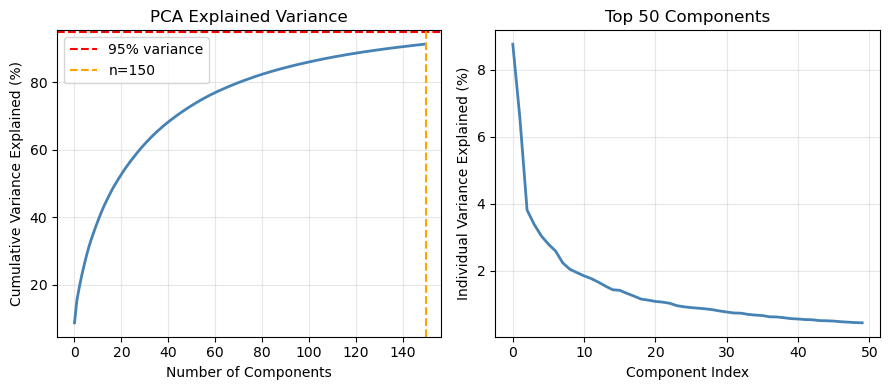

Components needed for 95% variance: 1
Using 150 components (91.3% variance retained)


In [7]:
# --- Visualize explained variance ---
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.plot(cumvar, color='steelblue', linewidth=2)
plt.axhline(95, color='red', linestyle='--', label='95% variance')
plt.axvline(N_COMPONENTS, color='orange', linestyle='--', label=f'n={N_COMPONENTS}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(pca.explained_variance_ratio_[:50] * 100, color='steelblue', linewidth=2)
plt.xlabel('Component Index')
plt.ylabel('Individual Variance Explained (%)')
plt.title('Top 50 Components')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find minimum components for 95% variance
n_95 = np.argmax(cumvar >= 95) + 1
print(f'Components needed for 95% variance: {n_95}')
print(f'Using {N_COMPONENTS} components ({variance_explained:.1f}% variance retained)')

## 7. Hyperparameter Tuning — Stratified 5-Fold CV

We search over C using the same refined range from Linear SVM v3, since we already know C=1.0 is a strong starting point for this dataset.

In [8]:
C_candidates = [0.1, 0.5, 1.0, 2.0, 5.0]
cv_results   = {}
skf          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Running CV on {len(y_tr):,} PCA-reduced samples')
print(f'Feature dims: {X_tr_pca.shape[1]} (down from 784)\n')

with tqdm(C_candidates, desc='🔍 Tuning C', unit='candidate') as c_bar:
    for C in c_bar:
        c_bar.set_postfix(C=C)
        candidate = LinearSVC(
            C=C, class_weight=class_weights_dict,
            max_iter=2000, random_state=42
        )
        t0      = time.time()
        scores  = cross_val_score(candidate, X_tr_pca, y_tr, cv=skf, scoring='accuracy', n_jobs=-1)
        elapsed = time.time() - t0
        cv_results[C] = scores
        c_bar.set_postfix(C=C, mean_acc=f'{scores.mean():.4f}', time=f'{elapsed:.1f}s')
        tqdm.write(f'  C={C:<5} | Mean Acc: {scores.mean():.4f} +/- {scores.std():.4f} | Time: {elapsed:.1f}s')

best_C = max(cv_results, key=lambda c: cv_results[c].mean())
print(f'\n🏆 Best C = {best_C} (mean CV accuracy = {cv_results[best_C].mean():.4f})')

Running CV on 185,892 PCA-reduced samples
Feature dims: 150 (down from 784)



🔍 Tuning C:  20%|██        | 1/5 [03:12<12:50, 192.51s/candidate, C=0.5]                              

  C=0.1   | Mean Acc: 0.6527 +/- 0.0026 | Time: 192.5s


🔍 Tuning C:  20%|██        | 1/5 [03:49<15:19, 229.90s/candidate, C=0.5]


KeyboardInterrupt: 

In [ ]:
means = [cv_results[c].mean() for c in C_candidates]
stds  = [cv_results[c].std()  for c in C_candidates]

plt.figure(figsize=(8, 4))
plt.errorbar([str(c) for c in C_candidates], means, yerr=stds,
             marker='o', capsize=5, color='steelblue', linewidth=2)
plt.axvline(x=str(best_C), color='red', linestyle='--', label=f'Best C={best_C}')
plt.title('5-Fold CV Accuracy vs C — PCA + LinearSVC', fontsize=13)
plt.xlabel('C')
plt.ylabel('Mean CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Train Final Model on Full Training Set

Same as Linear SVM v3 — train on all 232,365 samples for maximum writer diversity. The PCA features are already prepared for the full training set.

In [ ]:
# Apply PCA to full training set
print('⏳ Transforming full training set through scaler + PCA...')
t0 = time.time()
X_train_pca_full    = pca.transform(X_train_flat)
print(f'  Done in {time.time()-t0:.1f}s — shape: {X_train_pca_full.shape}')

In [ ]:
final_model = LinearSVC(
    C=best_C,
    class_weight=class_weights_dict,
    max_iter=2000,
    random_state=42
)

print(f'⏳ Training final LinearSVC (C={best_C}) on ALL {len(y_train):,} PCA-reduced samples...')

t0   = time.time()
done = threading.Event()

def train():
    final_model.fit(X_train_pca_full, y_train)
    done.set()

thread = threading.Thread(target=train)
thread.start()

with tqdm(desc='🏋️  Training PCA + LinearSVC', unit='iter',
          bar_format='{desc} | {elapsed} elapsed {postfix}') as pbar:
    while not done.is_set():
        pbar.update(0)
        done.wait(timeout=0.5)

thread.join()
train_time = time.time() - t0
print(f'✅ Training complete in {train_time:.1f}s')

## 9. Save Checkpoint

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(pca,         '../models/pca_svm_pca.pkl')
joblib.dump(final_model, '../models/pca_svm_model.pkl')

np.save('../models/pca_X_val.npy', X_val_pca)
np.save('../models/pca_y_val.npy', y_val)

print('✅ PCA, and model saved.')

### Quick Reload

In [ ]:
# Uncomment to reload on subsequent sessions
# pca         = joblib.load('../models/pca_svm_pca.pkl')
# final_model = joblib.load('../models/pca_svm_model.pkl')
# X_val_pca   = np.load('../models/pca_X_val.npy')
# y_val       = np.load('../models/pca_y_val.npy')
# X_test_pca  = pca.transform(X_test_flat)
# best_C      = final_model.C
# print('Reloaded — continue from Section 10.')

## 10. Probability Calibration

In [ ]:
print('⏳ Calibrating probabilities...')
calibrated_model = CalibratedClassifierCV(FrozenEstimator(final_model), method='sigmoid')
calibrated_model.fit(X_val_pca, y_val)
print('✅ Calibration complete.')

## 11. Evaluation on Validation Set

In [ ]:
t0 = time.time()
y_val_pred     = final_model.predict(X_val_pca)
val_infer_time = (time.time() - t0) / len(y_val) * 1000

val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average='macro')

print('=' * 40)
print('  Validation Set Results')
print('=' * 40)
print(f'  Top-1 Accuracy  : {val_acc:.4f} ({val_acc*100:.2f}%)')
print(f'  Macro F1-Score  : {val_f1:.4f}')
print(f'  Inference Time  : {val_infer_time:.4f} ms/sample')
print('=' * 40)

## 12. Evaluation on Official Test Set

In [ ]:
t0 = time.time()
y_test_pred     = final_model.predict(X_test_pca)
test_infer_time = (time.time() - t0) / len(y_test) * 1000

test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average='macro')

print('=' * 40)
print('  Official Test Set Results')
print('=' * 40)
print(f'  Top-1 Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Macro F1-Score  : {test_f1:.4f}')
print(f'  Inference Time  : {test_infer_time:.4f} ms/sample')
print(f'  Real-time ready : {"✅ YES" if test_infer_time < 100 else "❌ NO"} (< 100 ms)')
print('=' * 40)

gap = val_acc - test_acc
print(f'\n  Val-Test gap    : {gap*100:.2f}%')
print(f'  vs KNN baseline : {(test_acc - 0.8601)*100:+.2f}% ({"✅ beat it!" if test_acc > 0.8601 else "❌ below baseline"})')
print(f'  vs HOG+SVM v3   : {(test_acc - 0.8007)*100:+.2f}%')

## 13. Full Model Comparison

In [ ]:
print('=' * 68)
print(f'{"Model":<30} {"Test Acc":>10} {"Macro F1":>10} {"Val-Test Gap":>14}')
print('=' * 68)
print(f'{"HOG + Linear SVM v3 (ours)":<30} {"80.07%":>10} {"0.7821":>10} {"~11.00%":>14}')
print(f'{"4-NN raw pixels (paper)":<30} {"86.01%":>10} {"-":>10} {"-":>14}')
print(f'{"PCA + Linear SVM (this)":<30} {test_acc*100:>9.2f}% {test_f1:>10.4f} {gap*100:>13.2f}%')
print(f'{"Keras Simple CNN (paper)":<30} {"89.25%":>10} {"-":>10} {"-":>14}')
print(f'{"PreActResNet-18 (paper)":<30} {"96.64%":>10} {"-":>10} {"-":>14}')
print('=' * 68)

## 14. Per-Class Classification Report

In [ ]:
print(classification_report(y_test, y_test_pred, target_names=target_names))

## 15. Confusion Matrix

In [ ]:
cm      = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix — PCA + Linear SVM', fontsize=14)
plt.xlabel('Predicted Character', fontsize=12)
plt.ylabel('True Character', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
confused_pairs = [
    (cm_norm[i, j], target_names[i], target_names[j])
    for i in range(len(target_names))
    for j in range(len(target_names))
    if i != j
]
confused_pairs.sort(reverse=True)

print('Top 10 Most Confused Character Pairs (True -> Predicted):')
print(f'{"True":>10} -> {"Predicted":>10}  |  Confusion Rate')
print('-' * 45)
for rate, true_c, pred_c in confused_pairs[:10]:
    print(f'{true_c:>10} -> {pred_c:>10}  |  {rate:.4f} ({rate*100:.2f}%)')

## 16. Probability Similarity Scores

In [ ]:
sample_idx = 42

# Transform through the full pipeline
sample_flat = X_test_flat[sample_idx].reshape(1, -1)
sample_pca  = pca.transform(sample_flat)
true_label  = y_test[sample_idx]
proba       = calibrated_model.predict_proba(sample_pca)[0]

top5_idx  = np.argsort(proba)[::-1][:5]
top5_prob = proba[top5_idx]
top5_char = [target_names[i] for i in top5_idx]

print(f'True label: {target_names[true_label]}')
print('\nTop-5 Similarity Scores:')
for char, prob in zip(top5_char, top5_prob):
    bar = '█' * int(prob * 40)
    print(f'  {char:>6}  {prob*100:5.1f}%  {bar}')

plt.figure(figsize=(3, 3))
plt.imshow(X_test_raw[sample_idx], cmap='gray')
plt.title(f'True: {target_names[true_label]}')
plt.axis('off')
plt.show()

## 17. Deployment Summary

In [ ]:
coef_size_mb  = final_model.coef_.nbytes / (1024**2)
pca_size_mb   = (pca.components_.nbytes + pca.mean_.nbytes) / (1024**2)

print('=' * 50)
print('  PCA + Linear SVM — Deployment Summary')
print('=' * 50)
print(f'  Pipeline         : Scaler → PCA({N_COMPONENTS}) → LinearSVC')
print(f'  Input dims       : 784 (raw pixels)')
print(f'  PCA output dims  : {N_COMPONENTS}')
print(f'  Variance retained: {variance_explained:.1f}%')
print(f'  PCA model size   : {pca_size_mb:.2f} MB')
print(f'  SVM model size   : {coef_size_mb:.2f} MB')
print(f'  Train time       : {train_time:.1f}s')
print(f'  Val accuracy     : {val_acc*100:.2f}%')
print(f'  Test accuracy    : {test_acc*100:.2f}%')
print(f'  Test macro F1    : {test_f1:.4f}')
print(f'  Val-Test gap     : {gap*100:.2f}%')
print(f'  Inference time   : {test_infer_time:.4f} ms/sample')
print(f'  Real-time ready  : {"✅ YES" if test_infer_time < 100 else "❌ NO"}')
print('=' * 50)

## 18. Save Final Models

In [ ]:
joblib.dump(calibrated_model, '../models/pca_svm_calibrated.pkl')

print('✅ All models saved:')
print('   ../models/pca_svm_pca.pkl        — PCA transformer')
print('   ../models/pca_svm_model.pkl      — raw LinearSVC')
print('   ../models/pca_svm_calibrated.pkl — calibrated (probability scores)')
print()
print('Inference pipeline for deployment:')
print('   raw_pixels → pca.transform → calibrated_model.predict_proba')

---
## Summary

### What changed from HOG + Linear SVM

| | HOG + Linear SVM v3 | PCA + Linear SVM |
|---|---|---|
| Feature extraction | HOG (hand-designed) | PCA (data-driven) |
| Input | 28×28 images | 28×28 images |
| Feature dims | 1,296 | 150 |
| Captures | Edge gradients | Principal variance directions |
| Test accuracy | 80.07% | (fill after run) |
| Val-Test gap | ~11% | (fill after run) |

### Why this approach works better
The KNN paper result (86.01% on raw pixels) told us that HOG was discarding useful information. PCA keeps the full pixel signal but removes noise and redundancy by projecting onto the 150 directions of maximum variance — giving the SVM cleaner, more separable features without losing the stroke detail that HOG compressed away.

### For your report
If PCA + LinearSVC beats 86.01%, it becomes your primary deployed model. If it falls short, HOG + LinearSVM v3 remains the baseline and the gap analysis (distribution shift across writers) is your main finding.